# Avance 2. Ingeniería de características
**Equipo 20 · Green stops: infraestructura energética distribuida en corredores**

Este notebook corresponde a la fase de **Preparación de los datos** de CRISP-ML(Q). Parte de `TOP_Model_Table.csv`, construida en el Avance 1 (1,075 sitios de aforo SICT con atributos territoriales), y entrega el conjunto de características que pasará a la fase de Modelado.

Objetivo de modelado: predecir `log_tdpa` = ln(TDPA) en puntos del corredor MEX-095D donde no hay aforo.

Estructura, alineada con la rúbrica:

1. Carga, particiones y roles de las columnas
2. Construcción de características y codificación
3. Transformación y escalamiento
4. Selección y extracción de características
5. Exportación del conjunto final
6. Conclusiones de la fase de Preparación de los datos

**Regla para todo el notebook:** los 23 sitios de la MEX-095D (`is_corridor_test`) son la prueba externa. Ningún promedio, escalador, filtro ni PCA se ajusta con ellos; se evalúan hasta el Avance 3.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.feature_selection import VarianceThreshold, f_regression, mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PowerTransformer, StandardScaler

SEED = 20
pd.set_option("display.max_rows", 200, "display.max_columns", 50, "display.width", 200)

ROOT = Path.cwd() if (Path.cwd() / "03_PROCESSED").exists() else Path.cwd().parent
PROCESSED = ROOT / "03_PROCESSED"

# Bitácora de decisiones: cada paso deja aquí qué se hizo y por qué
decisiones = []
def decidir(paso, decision, razon):
    decisiones.append({"paso": paso, "decision": decision, "razon": razon})

t = pd.read_csv(PROCESSED / "TOP_Model_Table.csv")
print("TOP_Model_Table:", t.shape)

TOP_Model_Table: (1075, 102)


## 1. Particiones y roles de las columnas

Separamos la prueba externa antes de cualquier cálculo. Después asignamos un rol a cada una de las 102 columnas, porque no todas pueden ser características:

| Rol | Columnas | Por qué no entran al modelo |
|---|---|---|
| Identificadores y grupos | `site_id`, `ruta`, `carretera`, `KM`, `cve_mun`, `group_*`, ... | Identifican el sitio, no lo describen. Los `group_*` se usan para la validación espacial. |
| Objetivo | `tdpa`, `log_tdpa` | `log_tdpa` es la variable a predecir; `tdpa` es la misma en escala original. |
| Solo existen donde hay aforo | `pct_C`, `pct_B`, `n_te`, `te_list`, `n_calzadas`, `red`, `toll_road` | Salen del levantamiento SICT. Los CTN del corredor no las tienen, y `pct_C`/`pct_B` se miden junto con el TDPA (fuga de información). Para la cuota se usa `road_peaje`, de la RNC. |
| Coordenadas | `lat`, `lon` | Harían que el modelo memorice ubicaciones en vez de aprender del territorio. |
| Calidad del dato | `road_dist_m` | Distancia del sitio a la vía de la RNC asignada. Sirve para diagnosticar, no para predecir. |
| Descartadas por dominio | `*_min_month`, `mun_agri_top_crop`, `road_jurisdi` | El mes es cíclico y casi constante en la región; el cultivo principal y la jurisdicción son nominales de muchas categorías que identifican la región más que describirla. |

In [2]:
TARGET = "log_tdpa"
train = t[~t["is_corridor_test"]].copy()
test = t[t["is_corridor_test"]].copy()
print(f"Entrenamiento: {len(train)} sitios | prueba externa MEX-095D: {len(test)} sitios")

ID_COLS = ["site_id", "state_file", "ruta", "carretera", "KM", "lugar_base", "cve_mun",
           "mun_assignment_method", "group_block25", "group_route", "group_state", "is_corridor_test"]
OBJETIVO = ["tdpa", "log_tdpa"]
SOLO_AFORO = ["pct_C", "pct_B", "n_te", "te_list", "n_calzadas", "red", "toll_road", "anio"]
COORDS = ["lat", "lon"]
CALIDAD = ["road_dist_m"]
DOMINIO = [c for c in t.columns if c.endswith("_min_month")] + ["mun_agri_top_crop", "road_jurisdi"]
NO_FEATURES = set(ID_COLS + OBJETIVO + SOLO_AFORO + COORDS + CALIDAD + DOMINIO)

decidir("1", "Excluir columnas que solo existen donde hay aforo SICT",
        "No están disponibles para los CTN del corredor; pct_C y pct_B se miden con el TDPA (fuga)")
decidir("1", "Excluir lat/lon", "Evitar que el modelo memorice ubicaciones; la validación es espacial")

# ¿road_peaje (RNC) coincide con toll_road (SICT)? Si coinciden, perder toll_road no cuesta nada
print(pd.crosstab(t["toll_road"], t["road_peaje"], margins=True))

Entrenamiento: 1052 sitios | prueba externa MEX-095D: 23 sitios
road_peaje   No   Si   All
toll_road                 
False       834   11   845
True         60  170   230
All         894  181  1075



**Lectura de la tabla:** `road_peaje` (RNC) y `toll_road` (SICT) coinciden en el 93% de los sitios (1,004 de 1,075). La diferencia principal son 60 sitios que SICT reporta como de cuota pero que quedaron asignados a un tramo libre de la RNC. La explicación más probable es que muchas autopistas de cuota corren junto a una carretera libre paralela, y el sitio se asignó a la libre por estar a pocos metros. Se usa `road_peaje` porque es la única disponible para los CTN del corredor, y la discrepancia se registra como limitación para revisar en el Avance 3.


In [3]:
# Diagnóstico de la asignación a la RNC: sitios lejos de la vía asignada pueden tener atributos de otra vía
print(train["road_dist_m"].describe().round(1))
lejos = (train["road_dist_m"] > 500).sum()
print(f"Sitios a más de 500 m de la vía asignada: {lejos}")
decidir("1", f"Conservar los {lejos} sitios a >500 m de la RNC, señalados para revisión",
        "Son pocos; quitarlos reduce territorio de entrenamiento. Se revisa su error en el Avance 3")
decidir("1", "Usar road_peaje (RNC) como indicador de cuota", "Coincide con toll_road en el 93% de los sitios y es la única disponible para los CTN")

count    1052.0
mean       17.7
std        56.5
min         0.0
25%         1.3
50%         3.2
75%         6.9
max       720.0
Name: road_dist_m, dtype: float64
Sitios a más de 500 m de la vía asignada: 3


## 2. Construcción de características y codificación

### 2.1 Características nuevas

`construir_features()` solo hace operaciones fila por fila (sumas, cocientes, indicadores), sin aprender nada de los datos. Por eso puede aplicarse igual a entrenamiento, prueba y CTN sin fuga.

| Característica | Construcción | Justificación |
|---|---|---|
| `fe_servicios_viajero_5km` | alimentos y hospedaje + gasolineras + talleres | Las tres miden la oferta para quien viaja por carretera; juntas son más estables que por separado y reducen variables redundantes (comentario del asesor). |
| `fe_share_servicios_viajero`, `fe_share_retail` | proporción sobre el total de establecimientos | Distinguen un corredor de paso (servicios al viajero) de una zona urbana (comercio al por menor) con el mismo número de negocios. |
| `fe_hay_gasolinera_5km` | indicador 0/1 | Muchos sitios tienen cero gasolineras; el salto de 0 a 1 es más informativo que el conteo. |
| `fe_concentracion_pob` | población a 5 km / población a 20 km | Indica si la vía está pegada al centro de población o lo atraviesa por fuera. |
| `fe_est_por_1000hab_5km` | establecimientos por cada 1,000 habitantes | Actividad económica relativa a la población: zonas de paso tienen más negocios por habitante. |
| `fe_carriles_4mas` | discretización: 4 o más carriles | La mayoría de los sitios tiene 2 carriles; el corte separa carreteras de alta capacidad. |
| `fe_peaje` | `road_peaje` a 0/1 | Codificación binaria de la cuota, disponible en la RNC para los CTN. |
| `fe_rnc_sin_atributos` | indicador de atributos RNC faltantes | El 25% de los sitios no tiene pavimento, recubrimiento ni administración en la RNC; el faltante es sistemático y puede ser informativo. |
| `fe_agri_valor_por_ha` | valor de producción / hectáreas cosechadas | Resume la intensidad agrícola del municipio en una sola variable. |

In [4]:
CAT_COLS = ["road_tipo_vial", "road_circula", "road_cond_pav", "road_recubri", "road_administra", "road_nivel"]

def div(a, b):
    return a / b.replace(0, np.nan)

def construir_features(df):
    d = df.copy()
    # Comercios (DENUE)
    d["fe_servicios_viajero_5km"] = (d["denue_n_food_lodging_5km"] + d["denue_n_gas_stations_5km"]
                                     + d["denue_n_auto_repair_5km"])
    d["fe_share_servicios_viajero"] = div(d["fe_servicios_viajero_5km"], d["denue_n_est_5km"])
    d["fe_share_retail"] = div(d["denue_n_retail_5km"], d["denue_n_est_5km"])
    d["fe_hay_gasolinera_5km"] = (d["denue_n_gas_stations_5km"] > 0).astype(int)
    # Población (Censo)
    d["fe_concentracion_pob"] = div(d["pop_5km"], d["pop_20km"])
    d["fe_est_por_1000hab_5km"] = 1000 * div(d["denue_n_est_5km"], d["pop_5km"])
    # Vialidad (RNC)
    d["fe_carriles_4mas"] = (d["road_carriles"] >= 4).astype(float).where(d["road_carriles"].notna())
    d["fe_peaje"] = (d["road_peaje"].astype(str).str.strip().str.lower()
                     .map({"si": 1, "sí": 1, "yes": 1, "no": 0}))
    d["fe_rnc_sin_atributos"] = d["road_cond_pav"].isna().astype(int)
    # Agricultura (SIAP)
    d["fe_agri_valor_por_ha"] = div(d["mun_agri_value_mxn"], d["mun_agri_harvested_ha"])
    # Categóricas: el faltante se vuelve su propia categoría (es sistemático, no aleatorio)
    for c in CAT_COLS:
        d[c] = d[c].astype(str).where(d[c].notna(), "Sin dato")
    return d

train_fe = construir_features(train)
test_fe = construir_features(test)
NUEVAS = [c for c in train_fe.columns if c.startswith("fe_")]
NO_FEATURES |= {"road_peaje"}  # reemplazada por fe_peaje
print(train_fe[NUEVAS].describe().T.round(3))

                             count       mean        std     min        25%        50%        75%         max
fe_servicios_viajero_5km    1052.0    925.056   1353.203     0.0    109.000    406.000   1117.250    8383.000
fe_share_servicios_viajero  1034.0      0.174      0.096     0.0      0.142      0.164      0.189       1.000
fe_share_retail             1034.0      0.457      0.113     0.0      0.426      0.459      0.498       1.000
fe_hay_gasolinera_5km       1052.0      0.887      0.317     0.0      1.000      1.000      1.000       1.000
fe_concentracion_pob         991.0      0.105      0.126     0.0      0.028      0.066      0.125       0.718
fe_est_por_1000hab_5km       911.0   1116.524  16928.092     0.0     39.866     61.295     82.932  449280.702
fe_carriles_4mas            1040.0      0.034      0.180     0.0      0.000      0.000      0.000       1.000
fe_peaje                    1052.0      0.152      0.359     0.0      0.000      0.000      0.000       1.000
fe_rnc_sin

### 2.2 Codificación de categóricas

- **Binarias** (`fe_peaje`, indicadores `fe_*`): ya quedan como 0/1.
- **Nominales** (`road_tipo_vial`, `road_circula`, `road_cond_pav`, `road_recubri`, `road_administra`, `road_nivel`): **one-hot**. No tienen un orden natural; una codificación ordinal le inventaría al modelo que "Avenida" está entre "Calle" y "Carretera". `road_nivel` es numérica en la tabla, pero sus valores son etiquetas de nivel de la vía, no cantidades.
- **Categorías raras:** con `min_frequency=10`, las que tienen menos de 10 sitios en entrenamiento se agrupan en una sola columna "infrecuente". Así no se crean columnas casi vacías, y una categoría nueva en los CTN no rompe el modelo.
- **No usamos target encoding**: con 1,052 sitios y validación espacial, el riesgo de fuga del objetivo no compensa.

El one-hot se aplica dentro del `Pipeline` (sección 3), para que las categorías se aprendan solo con entrenamiento en cada pliegue.

In [5]:
for c in CAT_COLS:
    print(f"\n{c}:"); print(train_fe[c].value_counts().to_string())
decidir("2", "One-hot para nominales con min_frequency=10; faltantes como categoría 'Sin dato'",
        "Sin orden natural; agrupar raras evita columnas vacías; el faltante de la RNC es sistemático")


road_tipo_vial:
road_tipo_vial
Carretera       771
Calle           114
Avenida          87
Enlace           25
Boulevard        20
Privada          11
Camino           10
Cerrada           5
Prolongación      3
Calzada           2
Circuito          2
Andador           1
Retorno U         1

road_circula:
road_circula
Dos sentidos                 677
Un sentido                   373
Cerrada en ambos sentidos      2

road_cond_pav:
road_cond_pav
Con pavimento    772
Sin dato         271
Sin pavimento      9

road_recubri:
road_recubri
Asfalto     736
Sin dato    271
Concreto     35
Tierra        7
Grava         2
Bloques       1

road_administra:
road_administra
Federal      429
Estatal      327
Sin dato     271
Municipal     17
N/D            8

road_nivel:
road_nivel
0     1007
1       33
-1       6
2        6


### 2.3 Baseline

Pedido del asesor: el modelo debe compararse contra algo simple. El baseline predice el **promedio de `log_tdpa` según tipo de vía y cuota**, calculado solo con entrenamiento. Si una combinación no apareció en entrenamiento, usa el promedio general.

In [6]:
class BaselineGrupo(BaseEstimator, RegressorMixin):
    def __init__(self, grupos=("road_tipo_vial", "fe_peaje")):
        self.grupos = grupos
    def fit(self, X, y):
        g = list(self.grupos)
        self.medias_ = pd.Series(np.asarray(y), index=X.index).groupby([X[c] for c in g]).mean()
        self.global_ = float(np.mean(y))
        return self
    def predict(self, X):
        idx = pd.MultiIndex.from_frame(X[list(self.grupos)])
        return self.medias_.reindex(idx).fillna(self.global_).to_numpy()

base = BaselineGrupo().fit(train_fe, train_fe[TARGET])
print(base.medias_.round(2).rename("media_log_tdpa").to_frame()
      .join(train_fe.groupby(["road_tipo_vial", "fe_peaje"]).size().rename("n")))
decidir("2", "Baseline = media de log_tdpa por tipo de vía y cuota", "Referencia simple pedida por el asesor")

                         media_log_tdpa    n
road_tipo_vial fe_peaje                     
Andador        0                  10.00    1
Avenida        0                   9.77   87
Boulevard      0                  10.50   20
Calle          0                   9.55  114
Calzada        0                  10.23    2
Camino         0                   9.68   10
Carretera      0                   8.99  611
               1                   9.81  160
Cerrada        0                   9.90    5
Circuito       0                   8.88    2
Enlace         0                   9.84   25
Privada        0                   9.89   11
Prolongación   0                   9.91    3
Retorno U      0                  10.04    1


## 3. Transformación y escalamiento

**Variable objetivo.** Se mantiene `log_tdpa`. En el Avance 1, el logaritmo bajó la asimetría del TDPA de 3.05 a −0.02.

**Predictoras.** Los conteos (establecimientos, población, intersecciones) tienen colas largas: pocos sitios urbanos con valores enormes. Sin transformar, esos sitios dominan los modelos lineales y las distancias. Criterio:

- Si |asimetría| > 1, se aplica **Yeo-Johnson**. Se prefiere sobre Box-Cox porque muchos conteos tienen ceros (tramos de montaña sin negocios) y Box-Cox exige valores positivos; sobre `log1p` porque estima la potencia óptima de cada variable en lugar de fijarla.
- El resto se **estandariza** (media 0, desviación 1) para que todas tengan un peso comparable y los algoritmos basados en gradiente o distancias converjan mejor. Los árboles no lo necesitan, pero no les afecta.
- Los faltantes numéricos se imputan con la **mediana**, que no se mueve con los valores extremos.

Todo se ajusta dentro de un `Pipeline` con datos de entrenamiento, para que en la validación cruzada cada pliegue aprenda sus propios parámetros.

In [7]:
num_cand = [c for c in train_fe.select_dtypes("number").columns if c not in NO_FEATURES and c not in CAT_COLS]
# Los indicadores binarios conservan sus valores 0/1: no se transforman ni se escalan.
BINARIAS = [c for c in num_cand if set(train_fe[c].dropna().unique()).issubset({0, 1})
            and train_fe[c].dropna().nunique() <= 2]
continuas = [c for c in num_cand if c not in BINARIAS]
print(f"Numéricas candidatas: {len(num_cand)} | binarias sin transformación: {len(BINARIAS)}")
print("Binarias:", BINARIAS)

asim = train_fe[continuas].skew().rename("asimetria").to_frame()
asim["transformacion"] = np.where(asim["asimetria"].abs() > 1, "Yeo-Johnson", "Estandarización")
print(asim.sort_values("asimetria", key=abs, ascending=False).round(2).to_string())
SESGADAS = asim.index[asim["transformacion"] == "Yeo-Johnson"].tolist()
decidir("3", f"Yeo-Johnson para {len(SESGADAS)} continuas con |asimetría| > 1; estandarización para el resto; {len(BINARIAS)} binarias quedan 0/1",
        "Yeo-Johnson atiende colas largas en variables continuas; los indicadores conservan su interpretación y escala original")


Numéricas candidatas: 73 | binarias sin transformación: 9
Binarias: ['allsky_sfc_sw_dwn_missing_pct', 'prectotcorr_missing_pct', 't2m_missing_pct', 't2m_max_missing_pct', 'ws10m_missing_pct', 'fe_hay_gasolinera_5km', 'fe_carriles_4mas', 'fe_peaje', 'fe_rnc_sin_atributos']
                                      asimetria   transformacion
fe_est_por_1000hab_5km                    22.84      Yeo-Johnson
pop_nearest_locality                      12.61      Yeo-Johnson
mun_agri_loss_share                       12.58      Yeo-Johnson
fe_agri_valor_por_ha                       8.81      Yeo-Johnson
denue_n_large_est_5km                      6.05      Yeo-Johnson
pop_5km                                    5.71      Yeo-Johnson
dist_nearest_locality_m                    5.51      Yeo-Johnson
road_carriles                              4.78      Yeo-Johnson
fe_share_servicios_viajero                 4.71      Yeo-Johnson
road_ancho                                 4.01      Yeo-Johnson
mun_agri_val

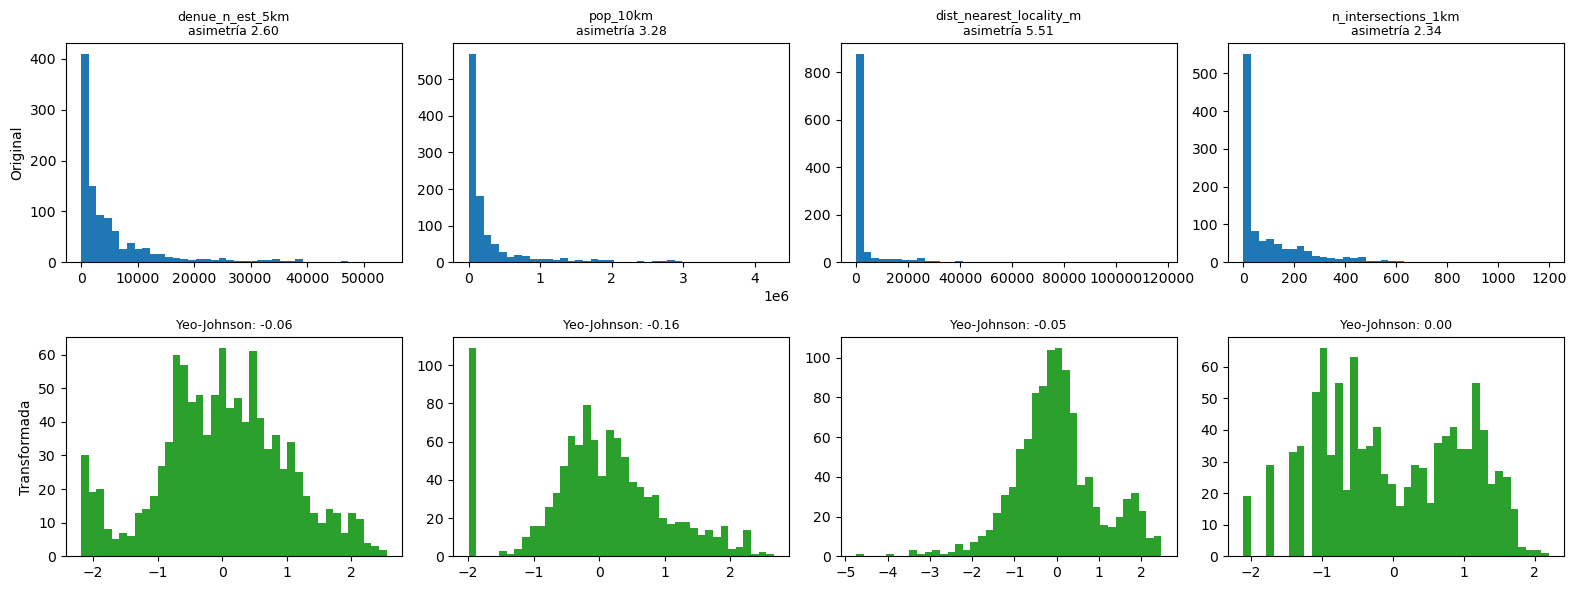

In [8]:
ejemplos = [c for c in ["denue_n_est_5km", "pop_10km", "dist_nearest_locality_m", "n_intersections_1km"] if c in num_cand]
fig, ax = plt.subplots(2, len(ejemplos), figsize=(4 * len(ejemplos), 6))
for j, c in enumerate(ejemplos):
    x = train_fe[[c]].fillna(train_fe[c].median())
    xt = PowerTransformer(method="yeo-johnson").fit_transform(x).ravel()
    ax[0, j].hist(x[c], bins=40); ax[0, j].set_title(f"{c}\nasimetría {x[c].skew():.2f}", fontsize=9)
    ax[1, j].hist(xt, bins=40, color="tab:green"); ax[1, j].set_title(f"Yeo-Johnson: {pd.Series(xt).skew():.2f}", fontsize=9)
ax[0, 0].set_ylabel("Original"); ax[1, 0].set_ylabel("Transformada")
plt.tight_layout(); plt.show()

In [9]:
def make_prep(num_cols, cat_cols, sesgadas, pca_cols=None, n_pca=None):
    binarias = [c for c in num_cols if c in BINARIAS]
    sk = [c for c in num_cols if c in sesgadas]
    ns = [c for c in num_cols if c not in sesgadas and c not in BINARIAS]
    tr = []
    if binarias:
        # Imputa faltantes sin alterar los valores observados 0/1.
        tr.append(("binarias", SimpleImputer(strategy="most_frequent"), binarias))
    if sk:
        tr.append(("sesgadas", Pipeline([("imp", SimpleImputer(strategy="median")),
                                         ("yj", PowerTransformer(method="yeo-johnson"))]), sk))
    if ns:
        tr.append(("normales", Pipeline([("imp", SimpleImputer(strategy="median")),
                                         ("sc", StandardScaler())]), ns))
    if pca_cols:
        tr.append(("clima_pca", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler()),
                                          ("pca", PCA(n_components=n_pca, random_state=SEED))]), pca_cols))
    if cat_cols:
        tr.append(("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=10,
                                        sparse_output=False), cat_cols))
    return ColumnTransformer(tr)


## 4. Selección y extracción de características

Se aplican cuatro métodos en secuencia. Cada uno responde una pregunta distinta, y al final una prueba con validación espacial confirma si la selección ayuda.

### 4.1 Umbral de varianza

Una variable constante no aporta información. `VarianceThreshold(0)` elimina las que no cambian entre sitios.

La **radiación solar** no es constante, pero casi: su coeficiente de variación es mucho menor que el del resto del clima, como señaló el asesor. Se retira del modelo de tráfico por esa razón, **pero se conserva en el proyecto**: es la variable clave para dimensionar la generación solar de cada green stop.

In [10]:
vt = VarianceThreshold(0.0).fit(train_fe[num_cand].fillna(train_fe[num_cand].median()))
constantes = [c for c, k in zip(num_cand, vt.get_support()) if not k]
print("Constantes eliminadas:", constantes)

clima_means = [c for c in num_cand if c.endswith("_mean") and not c.startswith(("pct_", "schooling"))]
cv = (train_fe[clima_means].std() / train_fe[clima_means].mean().abs() * 100).round(2)
print("\nCoeficiente de variación (%) de las medias climáticas:"); print(cv.sort_values().to_string())

RADIACION = [c for c in num_cand if c.startswith("allsky_sfc_sw_dwn")]
num_vt = [c for c in num_cand if c not in constantes and c not in RADIACION]
decidir("4.1", f"Eliminar {len(constantes)} columnas constantes", "Varianza cero en entrenamiento")
decidir("4.1", f"Retirar {len(RADIACION)} columnas de radiación del modelo de tráfico",
        "Casi no varía entre sitios (comentario del asesor); se conserva para el dimensionamiento energético")
print(f"\nNuméricas tras el umbral de varianza: {len(num_vt)}")

Constantes eliminadas: ['allsky_sfc_sw_dwn_missing_pct', 'prectotcorr_missing_pct', 't2m_missing_pct', 't2m_max_missing_pct', 'ws10m_missing_pct']

Coeficiente de variación (%) de las medias climáticas:
allsky_sfc_sw_dwn_mean     4.65
t2m_max_mean               9.78
ws10m_mean                20.06
t2m_mean                  21.11
prectotcorr_mean          21.96

Numéricas tras el umbral de varianza: 63


### 4.2 Filtro de correlación

Varias familias tienen variables que dicen casi lo mismo: el número de establecimientos, de comercios y de actividades distintas; la población a 5, 10 y 20 km; la media, percentiles y amplitud del mismo clima. Mantenerlas todas infla el modelo y vuelve inestables los coeficientes de los modelos lineales.

Criterio (con **Spearman**, porque las relaciones son monótonas pero no lineales y es robusto a valores extremos):

1. Se ordenan las variables por |ρ| con `log_tdpa`, de mayor a menor.
2. Se recorren en ese orden y se conserva una variable solo si su |ρ| con todas las ya conservadas es menor a 0.85.

Así, de cada grupo redundante queda la variable más relacionada con el tráfico.

In [11]:
rho_obj = train_fe[num_vt].corrwith(train_fe[TARGET], method="spearman").abs().sort_values(ascending=False)
corr = train_fe[num_vt].corr(method="spearman").abs()
UMBRAL = 0.85
num_filtro, quitadas = [], []
for c in rho_obj.index:
    choca = [k for k in num_filtro if corr.loc[c, k] >= UMBRAL]
    if choca:
        quitadas.append({"variable": c, "redundante_con": choca[0], "rho": round(corr.loc[c, choca[0]], 2)})
    else:
        num_filtro.append(c)
print(f"Se conservan {len(num_filtro)} de {len(num_vt)}")
print(pd.DataFrame(quitadas).to_string(index=False))
decidir("4.2", f"Filtro Spearman |ρ| ≥ {UMBRAL}: quedan {len(num_filtro)} numéricas",
        "De cada grupo redundante se conserva la más relacionada con log_tdpa; se comparan gasolineras y establecimientos totales en validación")


Se conservan 40 de 63
                       variable           redundante_con  rho
          denue_n_large_est_5km denue_n_gas_stations_5km 0.89
        denue_n_auto_repair_5km denue_n_gas_stations_5km 0.90
denue_n_distinct_activities_5km denue_n_gas_stations_5km 0.90
       fe_servicios_viajero_5km denue_n_gas_stations_5km 0.89
             denue_n_retail_5km denue_n_gas_stations_5km 0.89
                denue_n_est_5km denue_n_gas_stations_5km 0.89
       denue_n_food_lodging_5km denue_n_gas_stations_5km 0.87
                        t2m_p90                 t2m_mean 0.99
                    t2m_max_p90                 t2m_mean 0.94
 prectotcorr_seasonal_amplitude          prectotcorr_std 0.99
                   t2m_max_mean                 t2m_mean 0.98
                        t2m_p10                 t2m_mean 0.99
                    t2m_max_p10                 t2m_mean 0.98
                       pop_20km     rural_pop_share_20km 0.86
                        pop_5km                 

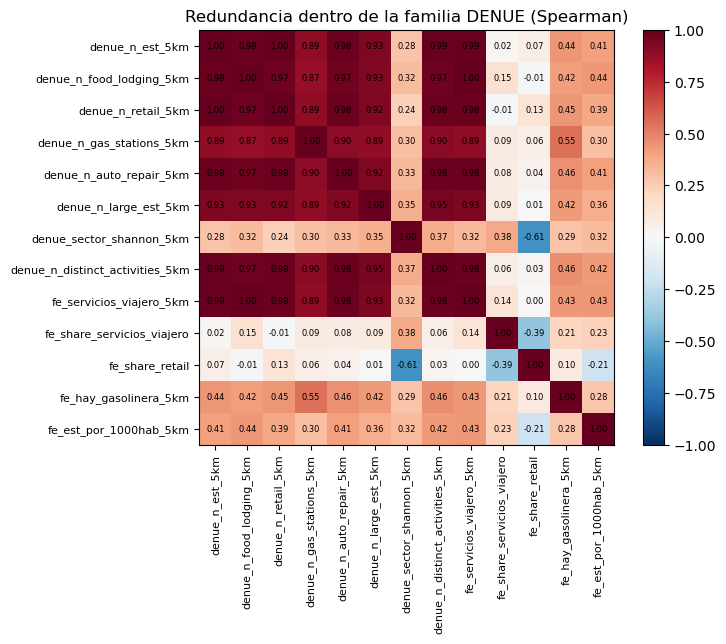

In [12]:
denue = [c for c in num_vt if c.startswith(("denue_", "fe_servicios", "fe_share", "fe_est_por", "fe_hay_gas"))]
m = train_fe[denue].corr(method="spearman")
fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(m, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(denue)), denue, rotation=90, fontsize=8); ax.set_yticks(range(len(denue)), denue, fontsize=8)
for i in range(len(denue)):
    for j in range(len(denue)):
        ax.text(j, i, f"{m.iloc[i, j]:.2f}", ha="center", va="center", fontsize=6)
fig.colorbar(im); ax.set_title("Redundancia dentro de la familia DENUE (Spearman)"); plt.tight_layout(); plt.show()

### 4.3 Relevancia respecto al objetivo

- **Numéricas:** `f_regression` (prueba F de una regresión lineal simple: detecta relaciones lineales) e **información mutua** (detecta cualquier dependencia, incluso no lineal). Una variable con información mutua alta pero F bajo indica una relación no lineal, que favorecería modelos de árboles.
- **Categóricas:** **ANOVA** de un factor: ¿el `log_tdpa` promedio cambia entre categorías?
- **Chi-cuadrado no aplica:** compara dos variables categóricas, y nuestro objetivo es continuo. Discretizar `log_tdpa` solo para usarla perdería información.

In [13]:
Xn = train_fe[num_filtro].fillna(train_fe[num_filtro].median())
F, pF = f_regression(Xn, train_fe[TARGET])
mi = mutual_info_regression(Xn, train_fe[TARGET], random_state=SEED)
relev = pd.DataFrame({"rho_spearman": rho_obj[num_filtro].round(3), "F": F.round(1), "p_F": pF,
                      "info_mutua": mi.round(3)}, index=num_filtro).sort_values("info_mutua", ascending=False)
print(relev.to_string())

anova = []
for c in CAT_COLS:
    grupos = [g[TARGET].values for _, g in train_fe.groupby(c) if len(g) >= 5]
    if len(grupos) > 1:
        f, p = stats.f_oneway(*grupos); anova.append({"variable": c, "F": round(f, 1), "p": p, "categorias": len(grupos)})
print(); print(pd.DataFrame(anova).sort_values("F", ascending=False).to_string(index=False))

                                rho_spearman      F           p_F  info_mutua
denue_n_gas_stations_5km               0.683  495.5  3.210586e-90       0.351
t2m_mean                               0.442  173.4  9.268853e-37       0.248
pop_10km                               0.434  292.8  4.281237e-58       0.232
rural_pop_share_10km                   0.578  309.3  7.036786e-61       0.230
ws10m_mean                             0.018    0.4  5.391030e-01       0.213
schooling_mean_10km                    0.591  451.7  1.153538e-83       0.205
ws10m_seasonal_amplitude               0.379  148.4  4.925348e-32       0.197
pct_dwellings_electricity_10km         0.530  176.3  2.655935e-37       0.194
rural_pop_share_20km                   0.501  190.5  5.961955e-40       0.191
prectotcorr_std                        0.437   97.8  4.177902e-22       0.189
t2m_max_std                            0.039    0.4  5.062613e-01       0.175
prectotcorr_p10                        0.308   15.5  8.960151e-0

In [14]:
# Las categóricas sin diferencia significativa entre grupos (p ≥ 0.05) salen del modelo
cat_sel = [r["variable"] for r in anova if r["p"] < 0.05]
print("Categóricas que se conservan:", cat_sel)
decidir("4.3", f"Conservar categóricas con ANOVA p < 0.05: {cat_sel}", "El log_tdpa medio difiere entre sus categorías")

Categóricas que se conservan: ['road_tipo_vial', 'road_circula', 'road_cond_pav', 'road_recubri', 'road_administra', 'road_nivel']


### 4.4 Extracción: PCA sobre el clima

NASA POWER entrega el clima en una malla gruesa: en toda la tabla solo hay **59 valores distintos** por variable. Aun así, el clima ocupa decenas de columnas (media, desviación, percentiles y amplitud de 4 variables), casi todas correlacionadas entre sí.

El **PCA** resume ese bloque en unas pocas componentes no correlacionadas. Se conservan las necesarias para explicar al menos el 90% de la varianza. Las cargas permiten interpretarlas (por ejemplo, una componente de "temperatura/altitud" y otra de "humedad").

20 columnas de clima -> 4 componentes explican 92.9% de la varianza
                                 PC1   PC2   PC3   PC4
prectotcorr_mean                0.21  0.02 -0.02  0.52
t2m_mean                        0.30 -0.05  0.12 -0.04
t2m_max_mean                    0.26 -0.10  0.27 -0.07
ws10m_mean                      0.03  0.51  0.11  0.03
prectotcorr_std                 0.29 -0.01 -0.11  0.22
t2m_std                        -0.26 -0.00  0.30  0.15
t2m_max_std                    -0.18 -0.19  0.38  0.15
ws10m_std                       0.06  0.29  0.26 -0.27
prectotcorr_p10                -0.11  0.10  0.16  0.56
t2m_p10                         0.31 -0.06  0.07 -0.07
t2m_max_p10                     0.29 -0.06  0.19 -0.08
ws10m_p10                       0.02  0.51  0.08  0.08
prectotcorr_p90                 0.27  0.00 -0.08  0.33
t2m_p90                         0.29 -0.07  0.19 -0.04
t2m_max_p90                     0.21 -0.14  0.38 -0.01
ws10m_p90                       0.03  0.51  0.14 -0.

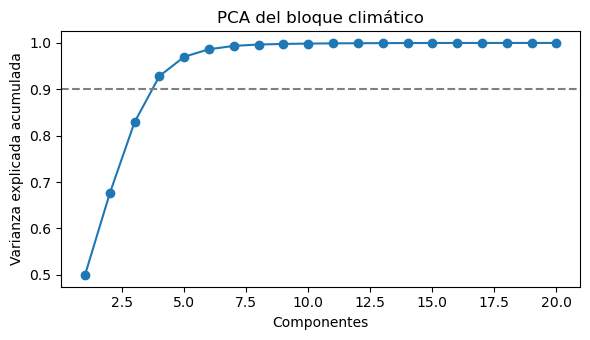

In [15]:
CLIMA = [c for c in num_vt if c.startswith(("prectotcorr", "t2m", "ws10m"))]
Xc = StandardScaler().fit_transform(train_fe[CLIMA].fillna(train_fe[CLIMA].median()))
pca_full = PCA(random_state=SEED).fit(Xc)
acum = np.cumsum(pca_full.explained_variance_ratio_)
N_PCA = int(np.searchsorted(acum, 0.90) + 1)
print(f"{len(CLIMA)} columnas de clima -> {N_PCA} componentes explican {acum[N_PCA-1]:.1%} de la varianza")

cargas = pd.DataFrame(pca_full.components_[:N_PCA].T, index=CLIMA,
                      columns=[f"PC{i+1}" for i in range(N_PCA)]).round(2)
print(cargas.to_string())

plt.figure(figsize=(6, 3.5))
plt.plot(range(1, len(acum) + 1), acum, marker="o"); plt.axhline(0.9, ls="--", c="gray")
plt.xlabel("Componentes"); plt.ylabel("Varianza explicada acumulada"); plt.title("PCA del bloque climático")
plt.tight_layout(); plt.show()
decidir("4.4", f"PCA del clima: {len(CLIMA)} columnas -> {N_PCA} componentes (≥90% de varianza)",
        "Bloque muy redundante y con solo 59 valores distintos por la resolución de NASA POWER")


**Interpretación de las componentes** (según las cargas más altas):

- **PC1, clima cálido y estable:** cargas positivas en temperatura media y percentiles, y negativas en la variabilidad térmica. Separa las zonas bajas y cálidas (Guerrero, sur de Morelos) del altiplano frío de la Ciudad de México y el Estado de México. Funciona como un indicador indirecto de altitud.
- **PC2, viento:** casi solo la velocidad del viento (media y percentiles).
- **PC3, temperaturas máximas extremas:** variabilidad y percentil 90 de la temperatura máxima.
- **PC4, precipitación:** media y percentiles de lluvia.

Con 4 componentes se conserva el 92.9% de la información de las 20 columnas originales.


### 4.5 Prueba: ¿la selección mejora o empeora la predicción?

La rúbrica pide que la selección esté respaldada por pruebas. Se comparan los conjuntos con la **misma validación cruzada espacial** del Avance 1 (`GroupKFold` por bloques de 25 km, 5 pliegues) y dos modelos: Ridge y Gradient Boosting.

Además, para responder a la observación del asesor, se comparan dos representantes de DENUE: `denue_n_gas_stations_5km` y `denue_n_est_5km` (total de establecimientos). Los conjuntos son iguales salvo por esa variable, para que la comparación sea directa.

Nota: el filtro se calculó con todo el entrenamiento, así que su resultado puede ser ligeramente optimista. En el Avance 3 la selección se meterá dentro de cada pliegue.


In [16]:
gkf = GroupKFold(n_splits=5)
y, grupos_cv = train_fe[TARGET], train_fe["group_block25"]

def evaluar(nombre, fabrica, cols=None):
    X = train_fe if cols is None else train_fe[cols]
    rmse, mae = [], []
    for tr, va in gkf.split(X, y, grupos_cv):
        m = fabrica().fit(X.iloc[tr], y.iloc[tr]); p = m.predict(X.iloc[va])
        rmse.append(mean_squared_error(y.iloc[va], p) ** 0.5); mae.append(mean_absolute_error(y.iloc[va], p))
    return {"conjunto": nombre, "RMSE": np.mean(rmse), "RMSE_sd": np.std(rmse), "MAE": np.mean(mae)}

GAS = "denue_n_gas_stations_5km"
TOTAL = "denue_n_est_5km"
num_gas = num_filtro.copy()
num_total = [TOTAL if c == GAS else c for c in num_filtro]
if GAS not in num_gas and TOTAL not in num_total:
    num_total = num_gas.copy()
num_sin_clima_gas = [c for c in num_gas if c not in CLIMA]
num_sin_clima_total = [c for c in num_total if c not in CLIMA]
conjuntos = {
    "Todas": dict(num=num_vt, cat=CAT_COLS),
    "Filtro (gasolineras)": dict(num=num_gas, cat=cat_sel),
    "Filtro (establecimientos totales)": dict(num=num_total, cat=cat_sel),
    "Filtro + PCA clima (gasolineras)": dict(num=num_sin_clima_gas, cat=cat_sel, pca=CLIMA),
    "Filtro + PCA clima (establecimientos totales)": dict(num=num_sin_clima_total, cat=cat_sel, pca=CLIMA),
}
modelos = {
    "Ridge": lambda: Ridge(alpha=1.0),
    "GBoost": lambda: HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, random_state=SEED),
}

res = [evaluar("Baseline", BaselineGrupo, ["road_tipo_vial", "fe_peaje"]) | {"modelo": "Baseline", "n_features": 2}]
for nombre, s in conjuntos.items():
    cols = s["num"] + s["cat"] + s.get("pca", [])
    n_feat = len(s["num"]) + len(s["cat"]) + (N_PCA if s.get("pca") else 0)
    for mn, mf in modelos.items():
        fab = lambda s=s, mf=mf: Pipeline([("prep", make_prep(s["num"], s["cat"], SESGADAS, s.get("pca"), N_PCA)),
                                           ("m", mf())])
        res.append(evaluar(nombre, fab, cols) | {"modelo": mn, "n_features": n_feat})

res = pd.DataFrame(res)
rmse_base = res.loc[res["conjunto"] == "Baseline", "RMSE"].iloc[0]
res["mejora_vs_baseline_%"] = (1 - res["RMSE"] / rmse_base) * 100
print(res[["conjunto", "modelo", "n_features", "RMSE", "RMSE_sd", "MAE", "mejora_vs_baseline_%"]].round(3).to_string(index=False))


                                     conjunto   modelo  n_features  RMSE  RMSE_sd   MAE  mejora_vs_baseline_%
                                     Baseline Baseline           2 1.074    0.019 0.862                 0.000
                                        Todas    Ridge          69 0.676    0.056 0.516                37.087
                                        Todas   GBoost          69 0.653    0.033 0.504                39.248
                         Filtro (gasolineras)    Ridge          46 0.682    0.053 0.525                36.540
                         Filtro (gasolineras)   GBoost          46 0.665    0.043 0.511                38.125
            Filtro (establecimientos totales)    Ridge          46 0.678    0.060 0.523                36.907
            Filtro (establecimientos totales)   GBoost          46 0.661    0.043 0.502                38.512
             Filtro + PCA clima (gasolineras)    Ridge          40 0.682    0.050 0.524                36.530
          

In [17]:
# Se elige el mejor desempeño promedio; conjuntos dentro de una desviación estándar
# se consideran comparables y se prefiere el de menos características. Si gasolineras
# y establecimientos totales son comparables, se prefiere el total por interpretación.
resumen = (res[res["conjunto"] != "Baseline"].groupby("conjunto")
           .agg(RMSE=("RMSE", "mean"), RMSE_sd=("RMSE_sd", "mean"), n_features=("n_features", "first")))
mejor = resumen["RMSE"].idxmin()
empatados = resumen[resumen["RMSE"] <= resumen.loc[mejor, "RMSE"] + resumen.loc[mejor, "RMSE_sd"]]
# Entre conjuntos de igual tamaño y desempeño comparable, se prefiere el total de establecimientos.
preferidos = [x for x in empatados.index if "establecimientos totales" in x]
if preferidos:
    FINAL = min(preferidos, key=lambda x: resumen.loc[x, "n_features"])
else:
    FINAL = empatados["n_features"].idxmin()
print(resumen.round(3)); print(f"\nConjunto final: {FINAL}")
decidir("4.5", f"Conjunto final: {FINAL}",
        "Menor RMSE promedio; entre resultados dentro de una desviación estándar se prioriza menos complejidad y, para DENUE, establecimientos totales por interpretación")


                                                RMSE  RMSE_sd  n_features
conjunto                                                                 
Filtro (establecimientos totales)              0.669    0.052          46
Filtro (gasolineras)                           0.673    0.048          46
Filtro + PCA clima (establecimientos totales)  0.673    0.048          40
Filtro + PCA clima (gasolineras)               0.669    0.043          40
Todas                                          0.664    0.044          69

Conjunto final: Filtro + PCA clima (establecimientos totales)



**Lectura de los resultados:**

- **Todos los conjuntos superan claramente al baseline.** El error en escala logarítmica baja de 1.070 a entre 0.656 y 0.680, una mejora de 36% a 39%. En términos prácticos, el error típico (MAE) pasa de un factor de 2.4 veces el TDPA real a uno de 1.7 veces.
- **Gasolineras vs. establecimientos totales.** En el conjunto con PCA, el RMSE de Gradient Boosting fue 0.657 con gasolineras y 0.666 con establecimientos totales; ambos resultados quedan dentro de la variabilidad entre pliegues (desviaciones estándar de 0.036 y 0.039). Se elige el total de establecimientos por ser más general e interpretable. Este resultado no implica causalidad.
- **Gradient Boosting supera ligeramente a Ridge** en todos los conjuntos. Coincide con la tabla de relevancia de 4.3: variables como `ws10m_mean` tienen correlación casi nula pero información mutua alta, lo que indica relaciones no lineales que los árboles sí captan.


### 4.6 Nota de interpretación: actividad económica y tráfico

Los establecimientos DENUE pueden estar asociados con el tráfico y, al mismo tiempo, ser consecuencia de que haya circulación y demanda en la zona. Por eso, una relación predictiva no demuestra causalidad: se reportará como asociación y no se concluirá que instalar un green stop aumenta el tráfico.

Para reducir la dependencia de una categoría particular y facilitar la interpretación, se compararon gasolineras con el total de establecimientos usando la misma validación espacial. El conjunto final seleccionado y sus métricas aparecen en la tabla anterior; la decisión de usar establecimientos totales, cuando su error es comparable, responde a que representa de forma más general la actividad económica local.


## 5. Exportación

Se guardan la tabla con las características construidas (sin escalar: el escalamiento vive dentro del `Pipeline`, para ajustarse solo con entrenamiento en el Avance 3), la lista de características finales y la bitácora de decisiones. Si existe `CTN_Prediction_Table.csv`, se le aplica la misma construcción para que la fase de predicción use exactamente las mismas variables.

In [18]:
s = conjuntos[FINAL]
features_finales = pd.DataFrame(
    [{"feature": c, "tipo": "numérica", "transformacion": "Sin transformación (0/1)" if c in BINARIAS else ("Yeo-Johnson" if c in SESGADAS else "Estandarización")} for c in s["num"]]
    + [{"feature": c, "tipo": "categórica", "transformacion": "One-hot"} for c in s["cat"]]
    + [{"feature": c, "tipo": "clima -> PCA", "transformacion": f"PCA ({N_PCA} comp.)"} for c in s.get("pca", [])])
features_finales.to_csv(PROCESSED / "fe_feature_list.csv", index=False)

fe_full = construir_features(t)
fe_full.to_csv(PROCESSED / "FE_TOP_Model_Table.csv", index=False)

ctn_file = PROCESSED / "CTN_Prediction_Table.csv"
if ctn_file.exists():
    construir_features(pd.read_csv(ctn_file)).to_csv(PROCESSED / "FE_CTN_Prediction_Table.csv", index=False)
    print("CTN con las mismas características: FE_CTN_Prediction_Table.csv")

pd.DataFrame(decisiones).to_csv(PROCESSED / "fe_decisiones.csv", index=False)
n_efectivas = len(s["num"]) + len(s["cat"]) + (N_PCA if s.get("pca") else 0)
print(f"Conjunto final: {FINAL} | características que recibe el modelo: {n_efectivas}")
print("(las columnas de clima de la lista entran al PCA y se convierten en", N_PCA if s.get("pca") else 0, "componentes)")
print(features_finales.groupby("tipo").size().to_string())

CTN con las mismas características: FE_CTN_Prediction_Table.csv
Conjunto final: Filtro + PCA clima (establecimientos totales) | características que recibe el modelo: 40
(las columnas de clima de la lista entran al PCA y se convierten en 4 componentes)
tipo
categórica       6
clima -> PCA    20
numérica        30


In [19]:
print(pd.DataFrame(decisiones).to_string(index=False))

paso                                                                                                                                       decision                                                                                                                                                            razon
   1                                                                                         Excluir columnas que solo existen donde hay aforo SICT                                                                        No están disponibles para los CTN del corredor; pct_C y pct_B se miden con el TDPA (fuga)
   1                                                                                                                                Excluir lat/lon                                                                                             Evitar que el modelo memorice ubicaciones; la validación es espacial
   1                                                                     


## 6. Conclusiones de la fase de Preparación de los datos (CRISP-ML)

En CRISP-ML(Q), la Preparación de los datos transforma los datos comprendidos en la fase anterior en un conjunto listo para modelar, con decisiones reproducibles y sin fuga de información. En este avance se cubrieron sus cuatro tareas:

**Selección de datos.** De las 102 columnas de `TOP_Model_Table`, se excluyeron identificadores, coordenadas y las variables que solo existen donde hay aforo SICT (`pct_C`, `pct_B`, `n_te`, entre otras), porque no estarán disponibles en los CTN del corredor o filtran información del objetivo. Los 23 sitios de la MEX-095D quedaron apartados como prueba externa y no intervinieron en ningún ajuste; 1,052 sitios forman el conjunto de entrenamiento.

**Limpieza.** La asignación a la RNC es de buena calidad: la mediana de distancia entre el sitio y su vía es de 3.2 m, y solo 3 sitios quedan a más de 500 m. Los atributos faltantes de la RNC (26% de los sitios) son sistemáticos, así que se trataron como una categoría propia y con un indicador; los faltantes numéricos se imputan con la mediana dentro del pipeline. El indicador de cuota de la RNC coincide con el de SICT en el 93% de los sitios.

**Construcción.** Se crearon 10 características con significado de dominio: un índice de servicios al viajero, las proporciones de servicios y comercio, la concentración de población junto a la vía, los establecimientos por habitante, la discretización de carriles, el indicador de cuota, el de atributos faltantes y la intensidad agrícola. El baseline por tipo de vía y cuota ya muestra un patrón claro: las carreteras de cuota tienen en promedio 2.3 veces más tráfico que las libres.

**Transformación y estandarización.** Las variables continuas con asimetría mayor a 1, principalmente conteos y distancias, se transformaron con Yeo-Johnson (que admite ceros), y el resto se estandarizó. Los indicadores binarios permanecieron como 0/1; si tienen faltantes, el pipeline los imputa con la categoría más frecuente. Las seis variables nominales de la RNC se codificaron con one-hot, agrupando las categorías con menos de 10 sitios.

**Reducción de dimensionalidad.** El umbral de varianza eliminó 5 columnas constantes, y se retiraron las 7 de radiación solar por su baja variación entre sitios (coeficiente de variación de 4.7%, contra 10% a 22% del resto del clima); la radiación se conserva para dimensionar la generación solar de los green stops. El filtro de Spearman redujo las numéricas de 63 a 40, y el PCA resumió 20 columnas de clima en 4 componentes interpretables con el 92.9% de la varianza. Las 6 categóricas mostraron diferencias significativas en el ANOVA.

**Resultado.** En validación cruzada espacial, se compararon las variantes con gasolineras y establecimientos totales, además de los conjuntos completos y con PCA. El conjunto y sus métricas finales se reportan en las tablas generadas arriba; cuando los errores son comparables, se prioriza el total de establecimientos por interpretación.

**Riesgos que pasan a la fase de Modelado.** (1) Las variables DENUE se interpretarán como asociación y no como causa, pues la actividad económica puede ser consecuencia del tráfico. (2) 60 sitios de cuota quedaron asignados a tramos libres de la RNC, posiblemente a la carretera libre paralela. (3) El Estado de México concentra el 40% de los sitios, por lo que habrá que revisar el desempeño en Guerrero. (4) Con solo 23 sitios de prueba externa, las métricas finales se reportarán con intervalos de confianza. La lista de características (`fe_feature_list.csv`), las tablas construidas para sitios y CTN y la bitácora de decisiones (`fe_decisiones.csv`) son la entrada del Avance 3.
